# BraTS 2021 / 2020 Brain Tumor Segmentation Training

Train a MONAI **SegResNet** model and save a checkpoint compatible with the current API output format:

- `0 = background`
- `1 = necrotic / non-enhancing core`
- `2 = edema`
- `3 = enhancing tumor`

BraTS original labels use `4` for enhancing tumor, so this notebook converts `4 → 3`.

## Cell 1 — Install dependencies

In [1]:
!pip install -q monai nibabel einops tqdm scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 29.3 MB/s eta 0:00:0000:0100:01


## Cell 2 — Imports and config

In [2]:
import os
import re
import glob
import random
import json
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

import monai
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd,
    NormalizeIntensityd, RandCropByPosNegLabeld, RandFlipd,
    RandScaleIntensityd, RandShiftIntensityd, EnsureTyped,
    MapTransform, AsDiscrete
)
from monai.data import Dataset, CacheDataset, DataLoader, decollate_batch
from monai.networks.nets import SegResNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.utils import set_determinism
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

set_determinism(seed=42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("MONAI:", monai.__version__)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Choose dataset automatically.
BRATS2021_ROOT = "/kaggle/input/datasets/dschettler8845/brats-2021-task1"
BRATS2020_ROOT = "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation"

DATA_ROOT = BRATS2020_ROOT

MAX_CASES = 200
VAL_SIZE = 0.15

ROI_SIZE = (128, 128, 128)
BATCH_SIZE = 1
NUM_SAMPLES = 2

MAX_EPOCHS = 30
VAL_INTERVAL = 2

LR = 5e-5
NUM_WORKERS = 2
CACHE_RATE = 0.08

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings(
    "ignore",
    message="Using a non-tuple sequence for multidimensional indexing is deprecated"
)

OUT_DIR = "/kaggle/working/segresnet_brats"
MODEL_DIR = f"{OUT_DIR}/models"
os.makedirs(MODEL_DIR, exist_ok=True)

BEST_MODEL_PATH = f"{MODEL_DIR}/SegResNet_BraTS_best.pth"
LAST_MODEL_PATH = f"{MODEL_DIR}/SegResNet_BraTS_last.pth"

print("Using DATA_ROOT:", DATA_ROOT)

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-28 16:25:03.465947: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777393503.946586      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777393504.057897      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777393505.087015      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777393505.087058      55 computation_placer.cc:1

Device: cuda
MONAI: 1.5.2
GPU: Tesla T4
Using DATA_ROOT: /kaggle/input/datasets/awsaf49/brats20-dataset-training-validation


## Cell 3 — Find BraTS cases robustly

This works with both BraTS 2021 and BraTS 2020 folder styles.

In [3]:
def find_brats_cases(root):
    root = Path(root)
    case_dirs = []
    for p in root.rglob("*"):
        if p.is_dir():
            files = list(p.glob("*.nii")) + list(p.glob("*.nii.gz"))
            names = [f.name.lower() for f in files]
            has_t1 = any(("_t1." in n or "_t1.nii" in n or "-t1" in n) and "t1ce" not in n for n in names)
            has_t1ce = any("t1ce" in n for n in names)
            has_t2 = any(("_t2." in n or "_t2.nii" in n or "-t2" in n) for n in names)
            has_flair = any("flair" in n for n in names)
            has_seg = any("seg" in n for n in names)
            if has_t1 and has_t1ce and has_t2 and has_flair and has_seg:
                case_dirs.append(p)
    return sorted(set(case_dirs))


def pick_file(case_dir, modality):
    files = list(Path(case_dir).glob("*.nii")) + list(Path(case_dir).glob("*.nii.gz"))
    files = sorted(files)
    modality = modality.lower()

    if modality == "t1":
        matches = [f for f in files if re.search(r"(_|-)?t1(\.|_|-|$)", f.name.lower()) and "t1ce" not in f.name.lower()]
    elif modality == "t1ce":
        matches = [f for f in files if "t1ce" in f.name.lower()]
    elif modality == "t2":
        matches = [f for f in files if re.search(r"(_|-)?t2(\.|_|-|$)", f.name.lower())]
    elif modality == "flair":
        matches = [f for f in files if "flair" in f.name.lower()]
    elif modality == "seg":
        matches = [f for f in files if "seg" in f.name.lower()]
    else:
        raise ValueError(modality)

    if not matches:
        raise FileNotFoundError(f"Missing {modality} in {case_dir}")
    return str(matches[0])


case_dirs = find_brats_cases(DATA_ROOT)
print("Found cases:", len(case_dirs))
print("Example case:", case_dirs[0] if case_dirs else "None")

data = []
for c in case_dirs:
    try:
        item = {
            "image": [pick_file(c, "t1"), pick_file(c, "t1ce"), pick_file(c, "t2"), pick_file(c, "flair")],
            "label": pick_file(c, "seg"),
            "case_id": Path(c).name,
        }
        data.append(item)
    except Exception as e:
        print("Skipped:", c, "|", e)

if MAX_CASES is not None:
    data = data[:MAX_CASES]

print("Usable cases:", len(data))
print(json.dumps(data[0], indent=2) if data else "No data found")

Found cases: 369
Example case: /kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001
Usable cases: 200
{
  "image": [
    "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t1.nii",
    "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t1ce.nii",
    "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_t2.nii",
    "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_001/BraTS20_Training_001_flair.nii"
  ],
  "label": "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/Bra

## Cell 4 — Train/validation split

In [12]:
train_files, val_files = train_test_split(
    data,
    test_size=VAL_SIZE,
    random_state=42,
    shuffle=True
)

# Safety check
if len(train_files) == 0 or len(val_files) == 0:
    raise RuntimeError("Train/Val split failed. Check dataset size.")

print("Train:", len(train_files))
print("Val:", len(val_files))

# Show example
print("Example train sample:")
print(json.dumps(train_files[0], indent=2))

Train: 170
Val: 30
Example train sample:
{
  "image": [
    "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_010/BraTS20_Training_010_t1.nii",
    "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_010/BraTS20_Training_010_t1ce.nii",
    "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_010/BraTS20_Training_010_t2.nii",
    "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_010/BraTS20_Training_010_flair.nii"
  ],
  "label": "/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_010/BraTS20_Training_010_seg.nii",
  "case_id": "BraTS20_Training_010"
}


## Cell 5 — Label converter

BraTS labels are originally `0, 1, 2, 4`. The API expects `0, 1, 2, 3`, so we convert `4 → 3` during training and validation.

In [5]:
class ConvertBraTSLabeld(MapTransform):
    def __init__(self, keys):
        super().__init__(keys)

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            label = torch.as_tensor(d[key]).long()

            # Convert BraTS labels: 4 → 3
            label[label == 4] = 3

            # Safety (اختياري)
            label[label > 3] = 0

            d[key] = label
        return d

## Cell 6 — Transforms

In [6]:
train_transforms = Compose([
    LoadImaged(keys=["image", "label"], image_only=True),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    ConvertBraTSLabeld(keys=["label"]),
    NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=ROI_SIZE,
        pos=1,
        neg=1,
        num_samples=NUM_SAMPLES,
        image_key="image",
        image_threshold=0,
    ),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    RandScaleIntensityd(keys=["image"], factors=0.1, prob=0.5),
    RandShiftIntensityd(keys=["image"], offsets=0.1, prob=0.5),
    EnsureTyped(keys=["image", "label"]),
])

val_transforms = Compose([
    LoadImaged(keys=["image", "label"], image_only=True),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    ConvertBraTSLabeld(keys=["label"]),
    NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True),
    EnsureTyped(keys=["image", "label"]),
])

## Cell 7 — Datasets and loaders

In [7]:
CACHE_RATE = 0.08

train_ds = CacheDataset(
    data=train_files,
    transform=train_transforms,
    cache_rate=CACHE_RATE,
    num_workers=NUM_WORKERS,
)

val_ds = CacheDataset(
    data=val_files,
    transform=val_transforms,
    cache_rate=CACHE_RATE,
    num_workers=NUM_WORKERS,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
)

val_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
)

# sanity check
batch = next(iter(train_loader))
print("Image:", batch["image"].shape)
print("Label:", batch["label"].shape)
print("Label values:", torch.unique(batch["label"]))

Loading dataset: 100%|██████████| 2/2 [00:07<00:00,  3.59s/it]


Image: torch.Size([2, 4, 128, 128, 128])
Label: torch.Size([2, 1, 128, 128, 128])
Label values: metatensor([0, 1, 2, 3])


## Cell 8 — Quick visualization

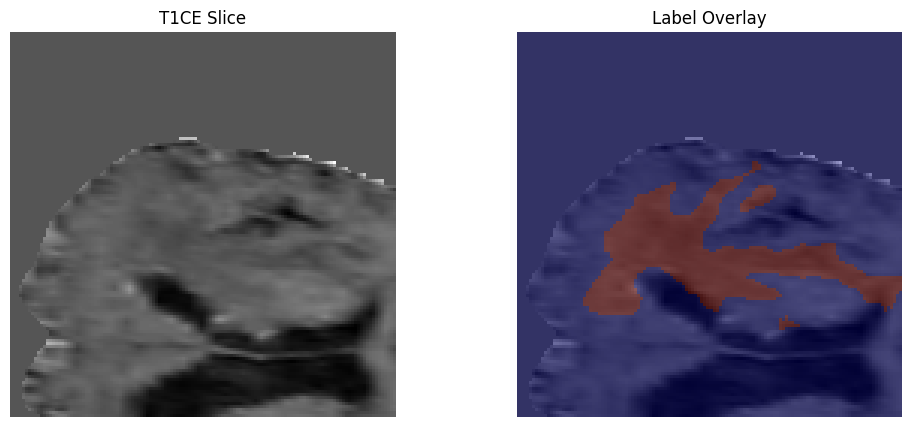

In [8]:
sample = batch

img = sample["image"][0, 1].detach().cpu().numpy()   # T1CE
lbl = sample["label"][0, 0].detach().cpu().numpy()

z = img.shape[-1] // 2

plt.figure(figsize=(12, 5))

# MRI
plt.subplot(1, 2, 1)
plt.imshow(img[:, :, z], cmap="gray")
plt.title("T1CE Slice")
plt.axis("off")

# Overlay
plt.subplot(1, 2, 2)
plt.imshow(img[:, :, z], cmap="gray")
plt.imshow(lbl[:, :, z], cmap="jet", alpha=0.4)  # 👈 مهم
plt.title("Label Overlay")
plt.axis("off")

plt.show()

## Cell 9 — Model, loss, optimizer

SegResNet is a practical upgrade over Standard U-Net while keeping the same 4-class mask output.

In [9]:
model = SegResNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=4,
    init_filters=32,
    blocks_down=(1, 2, 2, 4),
    blocks_up=(1, 1, 1),
    dropout_prob=0.2,
).to(DEVICE)

loss_function = DiceCELoss(
    to_onehot_y=True,
    softmax=True,
    include_background=False,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=MAX_EPOCHS
)

dice_metric = DiceMetric(
    include_background=False,
    reduction="mean"
)

post_pred = AsDiscrete(argmax=True, to_onehot=4)
post_label = AsDiscrete(to_onehot=4)

scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

print("Parameters:", sum(p.numel() for p in model.parameters()) / 1e6, "M")

Parameters: 18.79866 M


## Cell 10 — Validation function

In [10]:
@torch.no_grad()
def validate():
    model.eval()
    dice_metric.reset()

    val_bar = tqdm(val_loader, desc="Validation", leave=False)

    for batch_data in val_bar:
        val_inputs = batch_data["image"].to(DEVICE)
        val_labels = batch_data["label"].to(DEVICE)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            val_outputs = sliding_window_inference(
                val_inputs,
                roi_size=ROI_SIZE,
                sw_batch_size=1,
                predictor=model,
                overlap=0.5,
            )

        val_outputs_list = [post_pred(i) for i in decollate_batch(val_outputs)]
        val_labels_list = [post_label(i) for i in decollate_batch(val_labels)]

        dice_metric(y_pred=val_outputs_list, y=val_labels_list)

    mean_dice = dice_metric.aggregate().item()
    dice_metric.reset()

    return mean_dice

## Cell 11 — Training loop

In [11]:
best_metric = -1
best_epoch = -1
history = {"train_loss": [], "val_dice": []}

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{MAX_EPOCHS}", leave=True)

    for step, batch_data in enumerate(train_bar, start=1):
        inputs = batch_data["image"].to(DEVICE)
        labels = batch_data["label"].to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            outputs = model(inputs)
            loss = loss_function(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        train_bar.set_postfix(loss=loss.item())

    scheduler.step()

    epoch_loss /= max(step, 1)
    history["train_loss"].append(epoch_loss)

    print(f"Epoch {epoch}: train_loss={epoch_loss:.4f}")

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_metric": best_metric,
        "best_epoch": best_epoch,
        "history": history,
        "config": {
            "model": "SegResNet",
            "in_channels": 4,
            "out_channels": 4,
            "init_filters": 32,
            "blocks_down": (1, 2, 2, 4),
            "blocks_up": (1, 1, 1),
            "dropout_prob": 0.2,
            "labels": {
                "0": "background",
                "1": "necrotic_core",
                "2": "edema",
                "3": "enhancing_tumor"
            },
            "roi_size": ROI_SIZE,
            "modalities": ["t1", "t1ce", "t2", "flair"],
        }
    }

    if epoch % VAL_INTERVAL == 0:
        val_dice = validate()
        history["val_dice"].append({"epoch": epoch, "dice": val_dice})
        print(f"Epoch {epoch}: val_mean_dice={val_dice:.4f}")

        if val_dice > best_metric:
            best_metric = val_dice
            best_epoch = epoch
            checkpoint["best_metric"] = best_metric
            checkpoint["best_epoch"] = best_epoch
            checkpoint["history"] = history
            torch.save(checkpoint, BEST_MODEL_PATH)
            print(f"Saved new best model: {BEST_MODEL_PATH}")

    checkpoint["best_metric"] = best_metric
    checkpoint["best_epoch"] = best_epoch
    checkpoint["history"] = history
    torch.save(checkpoint, LAST_MODEL_PATH)

print("Training complete")
print("Best Dice:", best_metric)
print("Best epoch:", best_epoch)

Epoch 1/80:   0%|          | 0/170 [00:13<?, ?it/s]

Epoch 1: train_loss=1.4961


Epoch 2/80:   0%|          | 0/170 [00:00<?, ?it/s]

Epoch 2: train_loss=1.2405


Validation:   0%|          | 0/30 [00:00<?, ?it/s]

...

Epoch 79: train_loss=0.2553


Epoch 80/80:   0%|          | 0/170 [00:00<?, ?it/s]

Epoch 80: train_loss=0.2510


Validation:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 80: val_mean_dice=0.7835
Training complete
Best Dice: 0.7837051749229431
Best epoch: 58


## Cell 12 — Plot training history

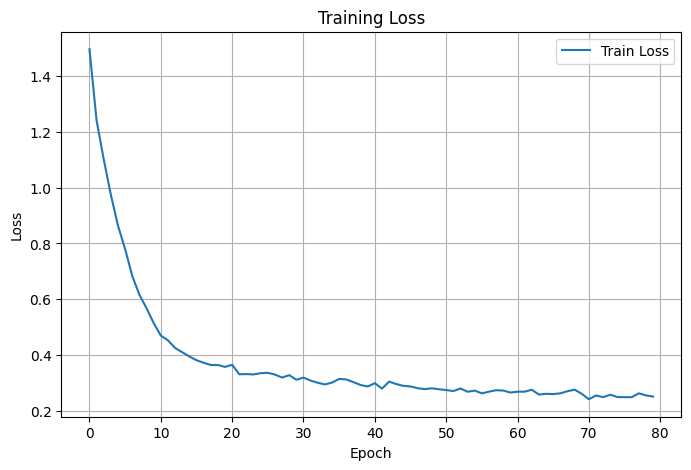

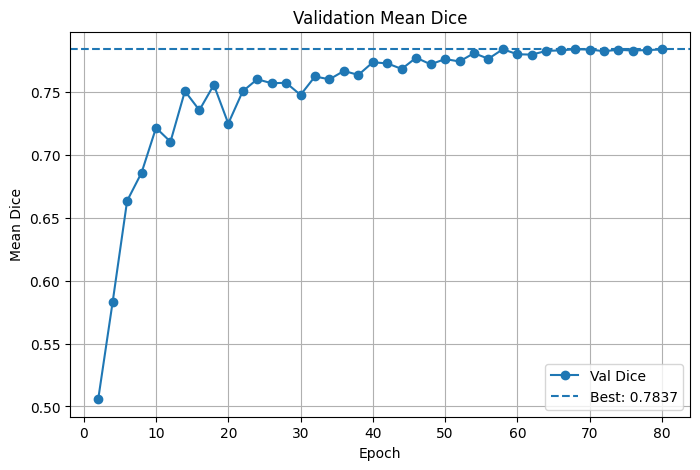

Best Dice: 0.7837051749229431


In [13]:
# Training Loss
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

# Validation Dice
if history["val_dice"]:
    xs = [x["epoch"] for x in history["val_dice"]]
    ys = [x["dice"] for x in history["val_dice"]]

    plt.figure(figsize=(8, 5))
    plt.plot(xs, ys, marker="o", label="Val Dice")
    plt.axhline(y=max(ys), linestyle="--", label=f"Best: {max(ys):.4f}")

    plt.title("Validation Mean Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Mean Dice")
    plt.grid(True)
    plt.legend()
    plt.show()

    print("Best Dice:", max(ys))

## Cell 13 — Test one validation case and visualize prediction

Testing on Case Index: 23


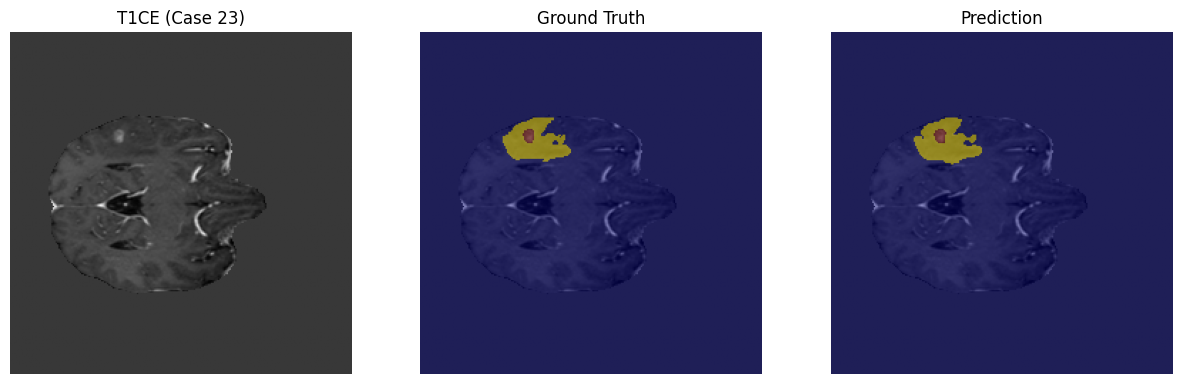

Case Index: 23
Pred unique labels: [0 1 2 3]
GT unique labels: [0 1 2 3]


In [22]:
import random

# 1. اختيار رقم عشوائي بين 0 ونهاية الـ dataset
idx = random.randint(0, len(val_ds) - 1)
print(f"Testing on Case Index: {idx}")

# 2. جلب الحالة بناءً على المؤشر العشوائي
case = val_ds[idx]

checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

image = case["image"].unsqueeze(0).to(DEVICE)
label = case["label"][0].detach().cpu().numpy().astype(np.uint8)

with torch.no_grad():
    with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
        pred_logits = sliding_window_inference(
            image,
            roi_size=ROI_SIZE,
            sw_batch_size=1,
            predictor=model,
            overlap=0.5,
        )

    pred = torch.argmax(pred_logits, dim=1)[0].detach().cpu().numpy().astype(np.uint8)

# استخدام قناة T1CE للعرض (عادة تكون Index 1 في BraTS)
img = case["image"][1].detach().cpu().numpy() 

# اختيار شريحة تحتوي على الورم للعرض بشكل أفضل
z_candidates = np.where(label.sum(axis=(0, 1)) > 0)[0]
z = z_candidates[len(z_candidates) // 2] if len(z_candidates) > 0 else img.shape[-1] // 2

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img[:, :, z], cmap="gray")
plt.title(f"T1CE (Case {idx})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img[:, :, z], cmap="gray")
plt.imshow(label[:, :, z], cmap="jet", alpha=0.45, vmin=0, vmax=3)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img[:, :, z], cmap="gray")
plt.imshow(pred[:, :, z], cmap="jet", alpha=0.45, vmin=0, vmax=3)
plt.title("Prediction")
plt.axis("off")

plt.show()

print(f"Case Index: {idx}")
print("Pred unique labels:", np.unique(pred))
print("GT unique labels:", np.unique(label))

## Cell 14 — Save training summary

In [15]:
summary = {
    "best_dice": float(best_metric),
    "best_epoch": int(best_epoch),
    "best_model_path": BEST_MODEL_PATH,
    "last_model_path": LAST_MODEL_PATH,

    "data_root": DATA_ROOT,
    "num_train": len(train_files),
    "num_val": len(val_files),

    "training_config": {
        "max_cases": MAX_CASES,
        "max_epochs": MAX_EPOCHS,
        "batch_size": BATCH_SIZE,
        "num_samples": NUM_SAMPLES,
        "roi_size": ROI_SIZE,
        "learning_rate": LR,
        "val_interval": VAL_INTERVAL,
    },

    "model_config": {
        "name": "SegResNet",
        "in_channels": 4,
        "out_channels": 4,
        "init_filters": 32,
        "blocks_down": (1, 2, 2, 4),
        "blocks_up": (1, 1, 1),
        "dropout_prob": 0.2,
    },

    "output_labels": {
        "0": "background",
        "1": "necrotic_core",
        "2": "edema",
        "3": "enhancing_tumor"
    },

    "modalities": ["t1", "t1ce", "t2", "flair"]
}

summary_path = f"{OUT_DIR}/training_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved summary to:", summary_path)
summary

Saved summary to: /kaggle/working/segresnet_brats/training_summary.json


{'best_dice': 0.7837051749229431,
 'best_epoch': 58,
 'best_model_path': '/kaggle/working/segresnet_brats/models/SegResNet_BraTS_best.pth',
 'last_model_path': '/kaggle/working/segresnet_brats/models/SegResNet_BraTS_last.pth',
 'data_root': '/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation',
 'num_train': 170,
 'num_val': 30,
 'training_config': {'max_cases': 200,
  'max_epochs': 80,
  'batch_size': 1,
  'num_samples': 2,
  'roi_size': (128, 128, 128),
  'learning_rate': 0.0001,
  'val_interval': 2},
 'model_config': {'name': 'SegResNet',
  'in_channels': 4,
  'out_channels': 4,
  'init_filters': 32,
  'blocks_down': (1, 2, 2, 4),
  'blocks_up': (1, 1, 1),
  'dropout_prob': 0.2},
 'output_labels': {'0': 'background',
  '1': 'necrotic_core',
  '2': 'edema',
  '3': 'enhancing_tumor'},
 'modalities': ['t1', 't1ce', 't2', 'flair']}

## Cell 15 — Export compatibility code for your API

Use the same output convention expected by your current backend.

In [ ]:
SEGMENTATION_PY_SNIPPET = r"""
import torch
import numpy as np
from monai.networks.nets import SegResNet
from monai.inferers import sliding_window_inference

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ROI_SIZE = (128, 128, 128)

def load_model(model_path):
    model = SegResNet(
        spatial_dims=3,
        in_channels=4,
        out_channels=4,
        init_filters=32,
        blocks_down=(1, 2, 2, 4),
        blocks_up=(1, 1, 1),
        dropout_prob=0.2,
    ).to(DEVICE)

    checkpoint = torch.load(model_path, map_location=DEVICE)
    state_dict = checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint

    model.load_state_dict(state_dict)
    model.eval()

    return model


@torch.no_grad()
def run_inference(model, input_volume):
    # input_volume must be shape: (4, H, W, D)
    x = torch.as_tensor(input_volume, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
        logits = sliding_window_inference(
            x,
            roi_size=ROI_SIZE,
            sw_batch_size=1,
            predictor=model,
            overlap=0.5,
        )

    mask = torch.argmax(logits, dim=1)[0].detach().cpu().numpy().astype(np.uint8)

    # Output labels:
    # 0 = background
    # 1 = necrotic core
    # 2 = edema
    # 3 = enhancing tumor

    return mask
"""

snippet_path = f"{OUT_DIR}/segmentation_api_snippet.py"

with open(snippet_path, "w") as f:
    f.write(SEGMENTATION_PY_SNIPPET)

print("Saved:", snippet_path)
print(SEGMENTATION_PY_SNIPPET)

## Cell 16 — Zip final outputs

In [16]:
import os
import shutil

# Safety checks
if not os.path.exists(BEST_MODEL_PATH):
    raise RuntimeError("Best model not found!")

if not os.path.exists(summary_path):
    raise RuntimeError("Summary file not found!")

print("Zipping outputs...")

zip_base = "/kaggle/working/segresnet_brats_outputs"
zip_path = shutil.make_archive(zip_base, "zip", OUT_DIR)

print("Created ZIP:", zip_path)
print("Best model:", BEST_MODEL_PATH)
print("Last model:", LAST_MODEL_PATH)
print("Summary:", summary_path)

Zipping outputs...
Created ZIP: /kaggle/working/segresnet_brats_outputs.zip
Best model: /kaggle/working/segresnet_brats/models/SegResNet_BraTS_best.pth
Last model: /kaggle/working/segresnet_brats/models/SegResNet_BraTS_last.pth
Summary: /kaggle/working/segresnet_brats/training_summary.json
